In [49]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

Alkaline stack

In [ ]:
# Parameters
cell_voltage = 1.9          # V
electrolyzer_power = 100    # MW
current_density = 1.0       # A/cm2
nickel_density = 8890       # kg/m3

# Calculate total current in A
# I = P / U
I = electrolyzer_power / cell_voltage * 1e6  # Convert MW to W, then W/V = A

# Calculate total area in m2
# A = I / j
A = I / current_density / 1e4  # Convert cm2 to m2

# Calculate mass of electrodes (anode + cathode) in kg
t_electrode = 1.0 / 1000  # mm to m
porosity = 0.5

m_anode   = (A * (t_electrode * nickel_density)) * porosity
m_cathode = (A * (t_electrode * nickel_density)) * porosity

# Calculate mass of catalysts in kg
# Loading in mg/cm2 → kg/m2: multiply by 0.01
anode_catalyst_loading   = 4.4 * 0.01  # mg/cm2 → kg/m2
cathode_catalyst_loading = 3.3 * 0.01  # mg/cm2 → kg/m2

m_anode_catalyst   = anode_catalyst_loading   * A  # kg/m2 × m2 = kg
m_cathode_catalyst = cathode_catalyst_loading * A  # kg/m2 × m2 = kg

# Calculate mass of bipolar plate in kg
t_BPP = 0.5 / 1000  # mm to m

m_BPP = A * (t_BPP * nickel_density)

# Total mass of nickel
total_mass    = m_anode + m_cathode + m_BPP + m_anode_catalyst + m_cathode_catalyst
mass_per_MW   = total_mass / electrolyzer_power

# Print results
print(f"Mass of nickel per MW:        {mass_per_MW:.2f} kg/MW")

Mass of nickel per MW:        705.89 kg/MW


## Sensitivity Analysis: Individual Effects Only

This section varies `cell_voltage` and `current_density` one-at-a-time to evaluate their impact on `mass_per_MW_new`.

- Tested cell voltages: 1.9, 1.8, 1.7 V (with current density fixed at baseline).
- Tested current densities: 0.5, 1.0, 2.0 A/cm2 (with cell voltage fixed at baseline).
- Separate plots are shown for each parameter (no combined 2D effect).

,parameter,value,mass_per_mw,pct_change_mass_per_mw
0,cell_voltage,1.9,949.8263,-10.5263
1,cell_voltage,1.8,1002.5944,-5.5556
2,cell_voltage,1.7,1061.5706,0.0000
3,current_density,0.5,1061.5706,0.0000
4,current_density,1.0,530.7853,-50.0000
5,current_density,2.0,265.3926,-75.0000


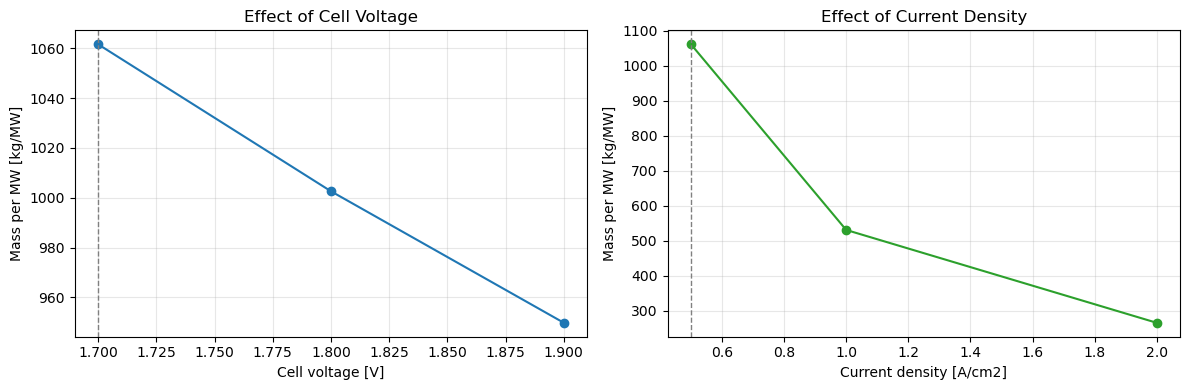

Baseline mass_per_MW: 1061.57 kg/MW


In [67]:
def mass_per_mw(cell_voltage_val, current_density_val):
    # Recompute using the same assumptions from the baseline cell.
    I_local = electrolyzer_power / cell_voltage_val * 1e3
    A_local = I_local / current_density_val / 1e3

    V_anode_local = A_local * (t_electrode_new / 1000)
    V_cathode_local = A_local * (t_electrode_new / 1000)
    m_anode_local = V_anode_local * nickel_density * porosity_new
    m_cathode_local = V_cathode_local * nickel_density * porosity_new

    m_anode_cat_local = ((new_anode_catalyst * 0.01) * A_local) * nickel_density
    m_cathode_cat_local = ((new_cathode_catalyst * 0.01) * A_local) * nickel_density

    V_BPP_local = A_local * (t_BPP_new / 1000)
    m_BPP_local = V_BPP_local * nickel_density

    total_mass_local = (
        m_anode_local
        + m_cathode_local
        + m_BPP_local
        + m_anode_cat_local
        + m_cathode_cat_local
    )
    return total_mass_local / electrolyzer_power


# Baseline from previous cell
baseline_voltage = cell_voltage
baseline_current_density = current_density
baseline_mass_per_mw = mass_per_mw(baseline_voltage, baseline_current_density)


# One-at-a-time sensitivity at requested values
voltage_values = np.array([1.9, 1.8, 1.7])
current_density_values = np.array([0.5, 1.0, 2.0])

voltage_results = []
for v in voltage_values:
    m = mass_per_mw(v, baseline_current_density)
    voltage_results.append(
        {
            "parameter": "cell_voltage",
            "value": v,
            "mass_per_mw": m,
            "pct_change_mass_per_mw": (m / baseline_mass_per_mw - 1) * 100,
        }
    )

current_density_results = []
for j in current_density_values:
    m = mass_per_mw(baseline_voltage, j)
    current_density_results.append(
        {
            "parameter": "current_density",
            "value": j,
            "mass_per_mw": m,
            "pct_change_mass_per_mw": (m / baseline_mass_per_mw - 1) * 100,
        }
    )

sensitivity_table = pd.DataFrame(voltage_results + current_density_results)
display(sensitivity_table.round(4))

# Prepare separate DataFrames
voltage_df = pd.DataFrame(voltage_results)
current_density_df = pd.DataFrame(current_density_results)

# Plot 1: effect of cell voltage only (current density fixed)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(
    voltage_df["value"],
    voltage_df["mass_per_mw"],
    marker="o",
    color="tab:blue",
)
axes[0].axvline(baseline_voltage, color="gray", linestyle="--", linewidth=1)
axes[0].set_title("Effect of Cell Voltage")
axes[0].set_xlabel("Cell voltage [V]")
axes[0].set_ylabel("Mass per MW [kg/MW]")
axes[0].grid(alpha=0.3)

# Plot 2: effect of current density only (cell voltage fixed)
axes[1].plot(
    current_density_df["value"],
    current_density_df["mass_per_mw"],
    marker="o",
    color="tab:green",
)
axes[1].axvline(baseline_current_density, color="gray", linestyle="--", linewidth=1)
axes[1].set_title("Effect of Current Density")
axes[1].set_xlabel("Current density [A/cm2]")
axes[1].set_ylabel("Mass per MW [kg/MW]")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Baseline mass_per_MW: {baseline_mass_per_mw:.2f} kg/MW")